In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Cleaned_SupplyChain_Data.csv')

In [3]:
df.head()

,Type,actual_shipping_days,scheduled_shipping_days,Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Name,Product Price,shipping_date,Shipping Mode,order_year,order_month,order_day,shipping_gap,late_flag,profit_margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,2018,1,Wednesday,-1,0,0.278413
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,2018,1,Saturday,1,1,-0.760000
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,2018,1,Saturday,0,0,-0.756003
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,2018,1,Saturday,-1,0,0.069748
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2018,1,Saturday,-2,0,0.409489


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Type                      180519 non-null  object 
 1   actual_shipping_days      180519 non-null  int64  
 2   scheduled_shipping_days   180519 non-null  int64  
 3   Benefit per order         180519 non-null  float64
 4   Sales per customer        180519 non-null  float64
 5   Delivery Status           180519 non-null  object 
 6   Late_delivery_risk        180519 non-null  int64  
 7   Category Id               180519 non-null  int64  
 8   Category Name             180519 non-null  object 
 9   Customer City             180519 non-null  object 
 10  Customer Country          180519 non-null  object 
 11  Customer Id               180519 non-null  int64  
 12  Customer Segment          180519 non-null  object 
 13  Customer State            180519 non-null  o

In [5]:
df.shape

(180519, 50)

In [6]:
df.describe()

,actual_shipping_days,scheduled_shipping_days,Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,net_sales,total_profit,Product Card Id,Product Category Id,Product Price,order_year,order_month,shipping_gap,late_flag,profit_margin
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35920.529950,5.443460,29.719955,...,183.107609,21.974989,692.509764,31.851451,141.232550,2015.971150,6.235449,0.565807,0.572793,0.108326
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.434755,1.629246,9.813646,...,120.043670,104.433526,336.446807,15.640064,139.732492,0.829429,3.403571,1.490966,0.494674,0.420594
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,0.000000,2.000000,-33.937553,...,7.490000,-4274.979980,19.000000,2.000000,9.990000,2015.000000,1.000000,-2.000000,0.000000,-2.750000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,104.379997,7.000000,403.000000,18.000000,50.000000,2015.000000,3.000000,0.000000,0.000000,0.062240
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,163.990005,31.520000,627.000000,29.000000,59.990002,2016.000000,6.000000,1.000000,1.000000,0.242512
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,247.399994,64.800003,1004.000000,45.000000,199.990005,2017.000000,9.000000,1.000000,1.000000,0.336014
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,1939.989990,911.799988,1363.000000,76.000000,1999.989990,2018.000000,12.000000,4.000000,1.000000,0.500443


In [7]:
plt.rcParams['figure.figsize'] = (10, 6)

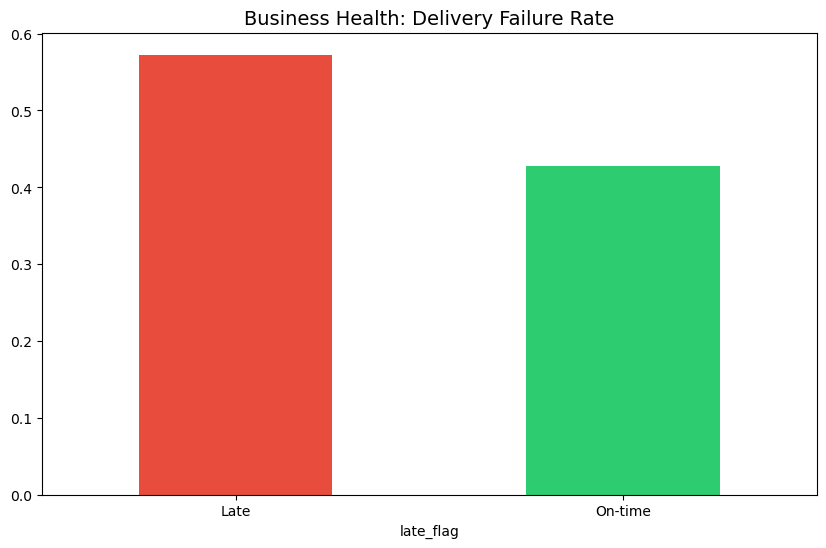

In [9]:
# Problem: 54.8% Risk is extremely high.
plt.figure()
df['late_flag'].value_counts(normalize=True).plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Business Health: Delivery Failure Rate', fontsize=14)
plt.xticks([0, 1], ['Late', 'On-time'], rotation=0)
plt.show()

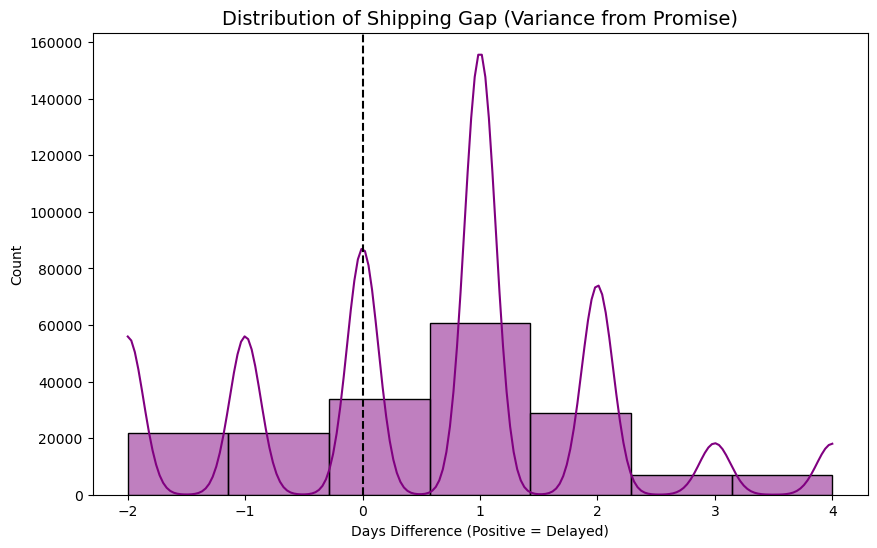

In [10]:
# Problem: How far off are we from our "Scheduled" promise?
plt.figure()
sns.histplot(df['shipping_gap'], bins=7, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Shipping Gap (Variance from Promise)', fontsize=14)
plt.xlabel('Days Difference (Positive = Delayed)')
plt.show()

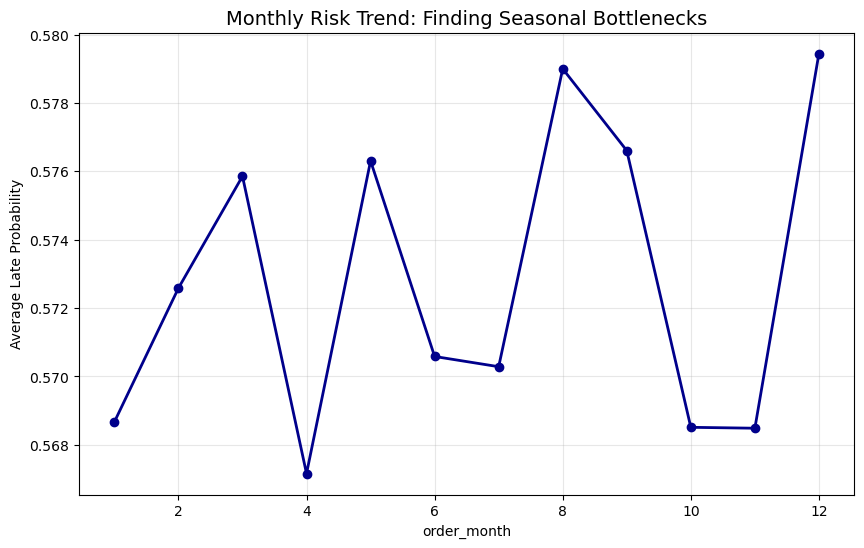

In [11]:
# Problem: Is the risk higher during specific months (e.g., holiday rush)?
plt.figure()
monthly_risk = df.groupby('order_month')['late_flag'].mean()
monthly_risk.plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Monthly Risk Trend: Finding Seasonal Bottlenecks', fontsize=14)
plt.ylabel('Average Late Probability')
plt.grid(True, alpha=0.3)
plt.show()

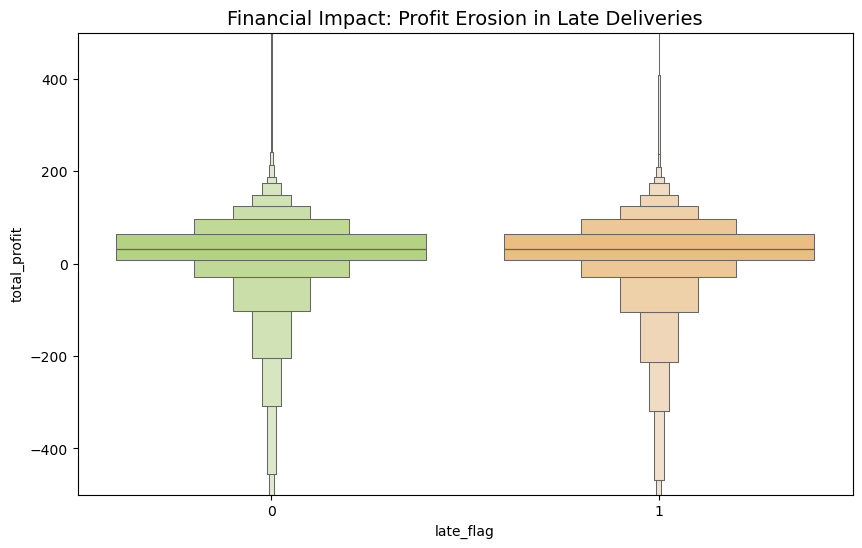

In [16]:
# Problem: Your min profit is -$4274. Are late orders the reason?
plt.figure()
sns.boxenplot(x='late_flag', y='total_profit', data=df, hue='late_flag', palette='RdYlGn_r', legend=False)
plt.ylim(-500, 500) # Zooming in to see the bulk of the data
plt.title('Financial Impact: Profit Erosion in Late Deliveries', fontsize=14)
plt.show()

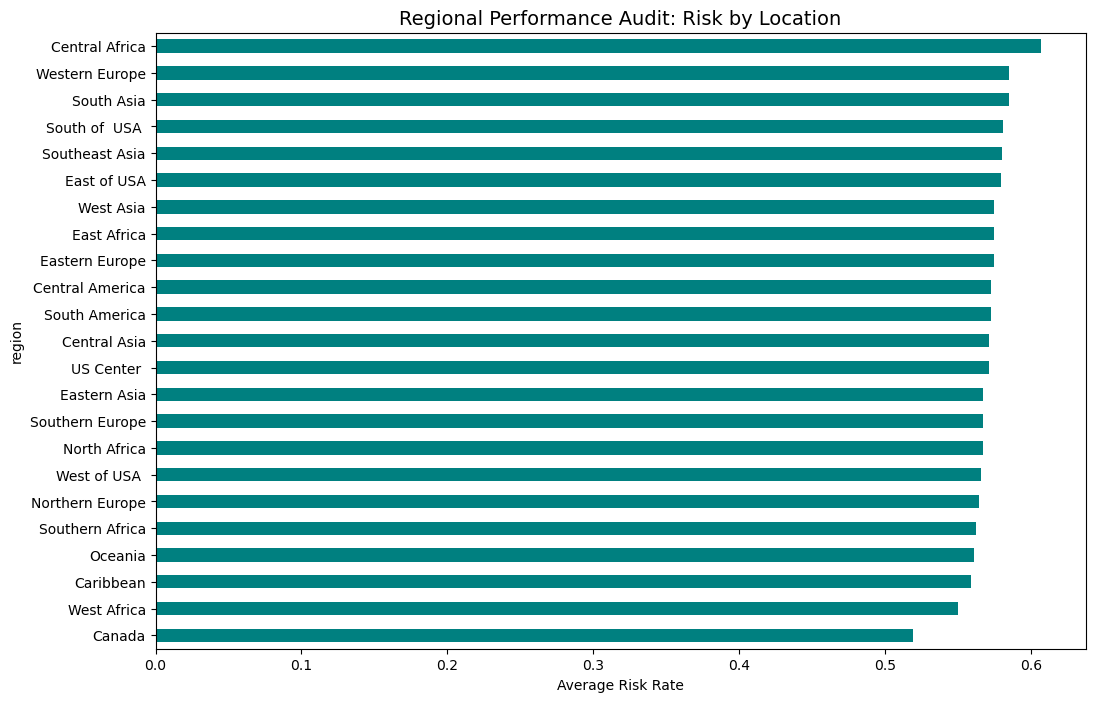

In [15]:
# Problem: Which regions have the worst fulfillment systems?
plt.figure(figsize=(12, 8))
region_risk = df.groupby('region')['late_flag'].mean().sort_values()
region_risk.plot(kind='barh', color='teal')
plt.title('Regional Performance Audit: Risk by Location', fontsize=14)
plt.xlabel('Average Risk Rate')
plt.show()

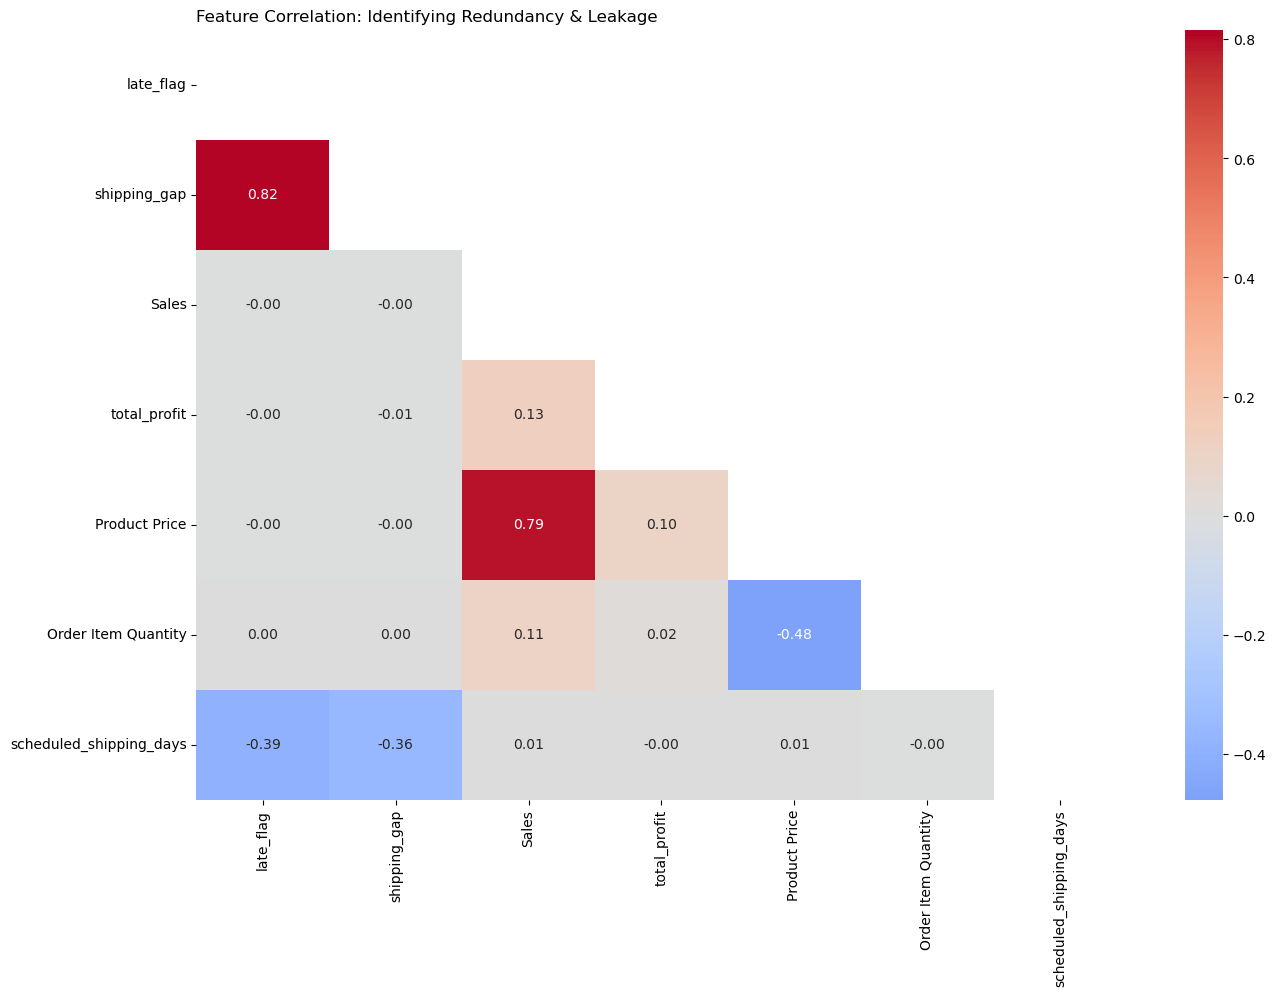

In [18]:
# --- 6. FEATURE CORRELATION for (ML PREP) ---
import numpy as np
plt.figure(figsize=(15, 10))

# Selecting only the core numerical columns to keep the map clean
cols = ['late_flag', 'shipping_gap', 'Sales', 'total_profit', 
                 'Product Price', 'Order Item Quantity', 'scheduled_shipping_days']

corr = df[cols].corr()

# Creating a mask to hide the redundant top half
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Feature Correlation: Identifying Redundancy & Leakage', loc='left')
plt.show()